###PHASE 5 : DRIFT DETECTION AND MODEL MONITORING

%md
## Setup — Imports, Constants, and Function Definitions

This cell consolidates all imports, constants, and function definitions used in this notebook. Running this single cell after a kernel restart restores all dependencies and lets the rest of the notebook run end-to-end without re-defining anything.

In [0]:
# ---- Imports ----
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.ml.feature import Bucketizer
from scipy.stats import ks_2samp

# ---- Constants ----
DATA_PATH = "dbfs:/Volumes/workspace/default/raw_data/decision_output"
OUTPUT_PATH = "dbfs:/Volumes/workspace/default/raw_data/drift_summary"
SPLIT_POINT = 368
NUM_BINS = 10
EPSILON = 1e-4
DRIFT_FACTOR = 3.0

FEATURES = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "is_high_risk_type",
    "balance_diff",
]

# ---- Functions ----
def compute_psi(reference_df, current_df, feature_name, num_bins=NUM_BINS, epsilon=EPSILON):
    """PSI between reference_df and current_df for one feature. Returns float or None."""
    quantile_probs = [i / num_bins for i in range(1, num_bins)]
    inner_edges = reference_df.approxQuantile(feature_name, quantile_probs, 0.001)
    unique_inner = sorted(set(inner_edges))
    if len(unique_inner) < 1:
        return None

    bin_edges = [float("-inf")] + unique_inner + [float("inf")]
    bucketizer = Bucketizer(splits=bin_edges, inputCol=feature_name, outputCol="bin")
    ref_binned = bucketizer.transform(reference_df)
    cur_binned = bucketizer.transform(current_df)

    ref_c = ref_binned.groupBy("bin").count().orderBy("bin").toPandas()
    cur_c = cur_binned.groupBy("bin").count().orderBy("bin").toPandas()

    merged = pd.merge(
        ref_c.rename(columns={"count": "ref_count"}),
        cur_c.rename(columns={"count": "cur_count"}),
        on="bin", how="outer"
    ).fillna(0)

    merged["ref_pct"] = merged["ref_count"] / merged["ref_count"].sum() + epsilon
    merged["cur_pct"] = merged["cur_count"] / merged["cur_count"].sum() + epsilon
    merged["psi_bin"] = (merged["cur_pct"] - merged["ref_pct"]) * \
                        np.log(merged["cur_pct"] / merged["ref_pct"])
    return float(merged["psi_bin"].sum())


def compute_ks(reference_df, current_df, feature_name):
    """KS two-sample test between reference and current for one feature."""
    ref_vals = reference_df.select(feature_name).toPandas()[feature_name].values
    cur_vals = current_df.select(feature_name).toPandas()[feature_name].values
    result = ks_2samp(ref_vals, cur_vals)
    return {"ks_statistic": float(result.statistic), "ks_pvalue": float(result.pvalue)}


print("Setup complete — imports, constants, and functions ready.")

Setup complete — imports, constants, and functions ready.


Step 1 — Loading the Dataset and Inspect the step Column

In [0]:
# Loading the decision-output table from Phase 4
df = spark.read.format("delta").load("dbfs:/Volumes/workspace/default/raw_data/decision_output")

# Showing how many rows and columns we have
print("Total rows:", df.count())
print("Total columns:", len(df.columns))

# Showing min, max of the step column
from pyspark.sql.functions import min as spark_min, max as spark_max
df.select(spark_min("step").alias("min_step"), spark_max("step").alias("max_step")).show()

Total rows: 49962
Total columns: 15
+------------------+--------+
|          min_step|max_step|
+------------------+--------+
|0.9912165081498902|   736.0|
+------------------+--------+



Step 2 — Splitting the Data into Reference and Current Windows

In [0]:
from pyspark.sql import functions as F

# Defining the split point (midpoint of step range)
SPLIT_POINT = 368

# Reference window: early time steps (training-era distribution)
reference_df = df.filter(F.col("step") <= SPLIT_POINT)

# Current window: later time steps (production-era distribution)
current_df = df.filter(F.col("step") > SPLIT_POINT)

# Verifying row counts
print("Reference window rows:", reference_df.count())
print("Current window rows:  ", current_df.count())
print("Total (should equal 49,962):", reference_df.count() + current_df.count())

Reference window rows: 40685
Current window rows:   9277
Total (should equal 49,962): 49962


Step 3 — Computing PSI for the amount Feature

In [0]:
import numpy as np

# ---- 1. Get min and max of `amount` from the REFERENCE window ----
stats = reference_df.select(
    F.min("amount").alias("min_val"),
    F.max("amount").alias("max_val")
).collect()[0]

min_val = stats["min_val"]
max_val = stats["max_val"]

print(f"Reference amount range: {min_val:.2f} to {max_val:.2f}")

# ---- 2. Build 10 equal-width bin edges ----
NUM_BINS = 10
bin_edges = np.linspace(min_val, max_val, NUM_BINS + 1)
print("Bin edges:", bin_edges)

Reference amount range: 0.92 to 36973901.85
Bin edges: [9.20000000e-01 3.69739101e+06 7.39478111e+06 1.10921712e+07
 1.47895613e+07 1.84869514e+07 2.21843415e+07 2.58817316e+07
 2.95791217e+07 3.32765118e+07 3.69739019e+07]


In [0]:
# Using quantile-based bins instead of equal-width
NUM_BINS = 10

# Computing the 10th, 20th, ..., 90th percentiles of `amount` in the reference window
quantile_probs = [i / NUM_BINS for i in range(1, NUM_BINS)]   # [0.1, 0.2, ..., 0.9]
inner_edges = reference_df.approxQuantile("amount", quantile_probs, 0.001)

# Building full bin edges: [min, q10, q20, ..., q90, max]
# We use -inf and +inf at the ends so any value in the current window fits somewhere
bin_edges = [float("-inf")] + inner_edges + [float("inf")]

print("Quantile-based bin edges for `amount`:")
for i, edge in enumerate(bin_edges):
    print(f"  edge {i}: {edge}")

Quantile-based bin edges for `amount`:
  edge 0: -inf
  edge 1: 4478.25
  edge 2: 9843.07
  edge 3: 18291.61
  edge 4: 37455.3
  edge 5: 75995.36
  edge 6: 123524.85
  edge 7: 177294.04
  edge 8: 245332.1
  edge 9: 363537.95
  edge 10: inf


Step 4 — Counting Rows Per Bin and Compute PSI for amount

In [0]:
from pyspark.ml.feature import Bucketizer

# ---- 1. Bucketize: assign each row to a bin ----
bucketizer = Bucketizer(splits=bin_edges, inputCol="amount", outputCol="bin")

ref_binned = bucketizer.transform(reference_df)
cur_binned = bucketizer.transform(current_df)

# ---- 2. Count rows per bin in each window ----
ref_counts = ref_binned.groupBy("bin").count().orderBy("bin").toPandas()
cur_counts = cur_binned.groupBy("bin").count().orderBy("bin").toPandas()

print("Reference counts per bin:")
print(ref_counts)
print("\nCurrent counts per bin:")
print(cur_counts)

Reference counts per bin:
   bin  count
0  0.0   4042
1  1.0   4080
2  2.0   4087
3  3.0   4045
4  4.0   4055
5  5.0   4102
6  6.0   4073
7  7.0   4061
8  8.0   4035
9  9.0   4105

Current counts per bin:
   bin  count
0  0.0    907
1  1.0    850
2  2.0    911
3  3.0    994
4  4.0   1031
5  5.0    899
6  6.0    946
7  7.0    863
8  8.0    923
9  9.0    953


Step 5 — Applying the PSI Formula and Get a Single PSI Number for amount

In [0]:
import pandas as pd

EPSILON = 1e-4   # tiny number to avoid log(0)

# ---- 1. Getting window sizes ----
ref_total = ref_counts["count"].sum()
cur_total = cur_counts["count"].sum()

# ---- 2. Merging ref and cur counts on bin (outer join keeps all bins) ----
merged = pd.merge(
    ref_counts.rename(columns={"count": "ref_count"}),
    cur_counts.rename(columns={"count": "cur_count"}),
    on="bin",
    how="outer"
).fillna(0).sort_values("bin").reset_index(drop=True)

# ---- 3. Converting counts to proportions (with epsilon for safety) ----
merged["ref_pct"] = merged["ref_count"] / ref_total + EPSILON
merged["cur_pct"] = merged["cur_count"] / cur_total + EPSILON

# ---- 4. Applying PSI formula bin by bin ----
merged["psi_bin"] = (merged["cur_pct"] - merged["ref_pct"]) * np.log(merged["cur_pct"] / merged["ref_pct"])

# ---- 5. Sum and interpret ----
psi_total = merged["psi_bin"].sum()

print(merged)
print(f"\nTotal PSI for `amount`: {psi_total:.4f}")

if psi_total < 0.10:
    verdict = "Stable — no significant drift"
elif psi_total < 0.25:
    verdict = "Moderate drift — investigate"
else:
    verdict = "Significant drift — model retraining likely needed"
print(f"Interpretation: {verdict}")

   bin  ref_count  cur_count   ref_pct   cur_pct   psi_bin
0  0.0       4042        907  0.099449  0.097869  0.000025
1  1.0       4080        850  0.100383  0.091724  0.000781
2  2.0       4087        911  0.100555  0.098300  0.000051
3  3.0       4045        994  0.099522  0.107247  0.000577
4  4.0       4055       1031  0.099768  0.111235  0.001248
5  5.0       4102        899  0.100923  0.097006  0.000155
6  6.0       4073        946  0.100211  0.102073  0.000034
7  7.0       4061        863  0.099916  0.093126  0.000478
8  8.0       4035        923  0.099277  0.099593  0.000001
9  9.0       4105        953  0.100997  0.102827  0.000033

Total PSI for `amount`: 0.0034
Interpretation: Stable — no significant drift


Step 6 — Generalising PSI to All 7 Features Using a Function

In [0]:
def compute_psi(feature_name, num_bins=10, epsilon=1e-4):
    """
    Compute PSI for one feature between reference_df and current_df.
    Returns a float (the PSI value), or None if the feature has too few unique values.
    """
    # 1. Building quantile-based bin edges from the reference window
    quantile_probs = [i / num_bins for i in range(1, num_bins)]
    inner_edges = reference_df.approxQuantile(feature_name, quantile_probs, 0.001)

    # 2. Deduplicate edges (low-cardinality features may produce repeats)
    unique_inner = sorted(set(inner_edges))
    if len(unique_inner) < 1:
        return None   # too few unique values to bin meaningfully

    bin_edges_local = [float("-inf")] + unique_inner + [float("inf")]

    # 3. Bucketize both windows
    bucketizer = Bucketizer(splits=bin_edges_local, inputCol=feature_name, outputCol="bin")
    ref_binned = bucketizer.transform(reference_df)
    cur_binned = bucketizer.transform(current_df)

    # 4. Counting rows per bin
    ref_c = ref_binned.groupBy("bin").count().orderBy("bin").toPandas()
    cur_c = cur_binned.groupBy("bin").count().orderBy("bin").toPandas()

    # 5. Computing PSI
    ref_total_local = ref_c["count"].sum()
    cur_total_local = cur_c["count"].sum()

    merged_local = pd.merge(
        ref_c.rename(columns={"count": "ref_count"}),
        cur_c.rename(columns={"count": "cur_count"}),
        on="bin", how="outer"
    ).fillna(0)

    merged_local["ref_pct"] = merged_local["ref_count"] / ref_total_local + epsilon
    merged_local["cur_pct"] = merged_local["cur_count"] / cur_total_local + epsilon
    merged_local["psi_bin"] = (merged_local["cur_pct"] - merged_local["ref_pct"]) * \
                              np.log(merged_local["cur_pct"] / merged_local["ref_pct"])

    return float(merged_local["psi_bin"].sum())


# ---- Applying to all 7 features ----
features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "is_high_risk_type",
    "balance_diff",
]

psi_results = []
for feat in features:
    psi_value = compute_psi(feat)
    psi_results.append({"feature": feat, "psi": psi_value})

psi_df = pd.DataFrame(psi_results)
print(psi_df)

             feature       psi
0             amount  0.003383
1      oldbalanceOrg  0.001571
2     newbalanceOrig  0.000826
3     oldbalanceDest  0.001411
4     newbalanceDest  0.002535
5  is_high_risk_type  0.000181
6       balance_diff  0.000934


Step 7 — Kolmogorov–Smirnov (KS) Test for All 7 Features

In [0]:
# Re-define variables in case the kernel was reset
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.ml.feature import Bucketizer

# Reload the data
df = spark.read.format("delta").load("dbfs:/Volumes/workspace/default/raw_data/decision_output")

# Re-create the temporal split
SPLIT_POINT = 368
reference_df = df.filter(F.col("step") <= SPLIT_POINT)
current_df = df.filter(F.col("step") > SPLIT_POINT)

# Re-define the features list
features = [
    "amount",
    "oldbalanceOrg",
    "newbalanceOrig",
    "oldbalanceDest",
    "newbalanceDest",
    "is_high_risk_type",
    "balance_diff",
]

print("Variables restored.")
print("Features:", features)
print("Reference rows:", reference_df.count())
print("Current rows:  ", current_df.count())

Variables restored.
Features: ['amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest', 'is_high_risk_type', 'balance_diff']
Reference rows: 40685
Current rows:   9277


In [0]:
from scipy.stats import ks_2samp

def compute_ks(feature_name):
    """
    Compute the KS two-sample test for a feature between reference and current windows.
    Returns a dict with the KS statistic and p-value.
    """
    # Pulling feature values from Spark into Python (safe — small data)
    ref_vals = reference_df.select(feature_name).toPandas()[feature_name].values
    cur_vals = current_df.select(feature_name).toPandas()[feature_name].values

    # Running the KS two-sample test
    result = ks_2samp(ref_vals, cur_vals)

    return {
        "ks_statistic": float(result.statistic),
        "ks_pvalue": float(result.pvalue),
    }

# Applying KS to all 7 features
ks_results = []
for feat in features:
    ks_out = compute_ks(feat)
    ks_results.append({
        "feature": feat,
        "ks_statistic": ks_out["ks_statistic"],
        "ks_pvalue": ks_out["ks_pvalue"],
    })

ks_df = pd.DataFrame(ks_results)
print(ks_df)

             feature  ks_statistic  ks_pvalue
0             amount      0.013640   0.119167
1      oldbalanceOrg      0.013607   0.120804
2     newbalanceOrig      0.007354   0.805752
3     oldbalanceDest      0.011117   0.305720
4     newbalanceDest      0.015127   0.062398
5  is_high_risk_type      0.006672   0.887404
6       balance_diff      0.015102   0.063126


Step 8 — Combining PSI + KS into a Single Drift Summary Table

In [0]:
# ---- Re-building PSI results ----
def compute_psi(feature_name, num_bins=10, epsilon=1e-4):
    quantile_probs = [i / num_bins for i in range(1, num_bins)]
    inner_edges = reference_df.approxQuantile(feature_name, quantile_probs, 0.001)
    unique_inner = sorted(set(inner_edges))
    if len(unique_inner) < 1:
        return None

    bin_edges_local = [float("-inf")] + unique_inner + [float("inf")]
    bucketizer = Bucketizer(splits=bin_edges_local, inputCol=feature_name, outputCol="bin")
    ref_binned = bucketizer.transform(reference_df)
    cur_binned = bucketizer.transform(current_df)

    ref_c = ref_binned.groupBy("bin").count().orderBy("bin").toPandas()
    cur_c = cur_binned.groupBy("bin").count().orderBy("bin").toPandas()

    ref_total_local = ref_c["count"].sum()
    cur_total_local = cur_c["count"].sum()

    merged_local = pd.merge(
        ref_c.rename(columns={"count": "ref_count"}),
        cur_c.rename(columns={"count": "cur_count"}),
        on="bin", how="outer"
    ).fillna(0)

    merged_local["ref_pct"] = merged_local["ref_count"] / ref_total_local + epsilon
    merged_local["cur_pct"] = merged_local["cur_count"] / cur_total_local + epsilon
    merged_local["psi_bin"] = (merged_local["cur_pct"] - merged_local["ref_pct"]) * \
                              np.log(merged_local["cur_pct"] / merged_local["ref_pct"])

    return float(merged_local["psi_bin"].sum())


# ---- Re-building KS results ----
from scipy.stats import ks_2samp

def compute_ks(feature_name):
    ref_vals = reference_df.select(feature_name).toPandas()[feature_name].values
    cur_vals = current_df.select(feature_name).toPandas()[feature_name].values
    result = ks_2samp(ref_vals, cur_vals)
    return {"ks_statistic": float(result.statistic), "ks_pvalue": float(result.pvalue)}


# ---- Running both for all features ----
psi_results = []
ks_results = []
for feat in features:
    psi_results.append({"feature": feat, "psi": compute_psi(feat)})
    ks_out = compute_ks(feat)
    ks_results.append({
        "feature": feat,
        "ks_statistic": ks_out["ks_statistic"],
        "ks_pvalue": ks_out["ks_pvalue"],
    })

psi_df = pd.DataFrame(psi_results)
ks_df = pd.DataFrame(ks_results)

print("PSI results:")
print(psi_df)
print("\nKS results:")
print(ks_df)

PSI results:
             feature       psi
0             amount  0.003383
1      oldbalanceOrg  0.001571
2     newbalanceOrig  0.000826
3     oldbalanceDest  0.001411
4     newbalanceDest  0.002535
5  is_high_risk_type  0.000181
6       balance_diff  0.000934

KS results:
             feature  ks_statistic  ks_pvalue
0             amount      0.013640   0.119167
1      oldbalanceOrg      0.013607   0.120804
2     newbalanceOrig      0.007354   0.805752
3     oldbalanceDest      0.011117   0.305720
4     newbalanceDest      0.015127   0.062398
5  is_high_risk_type      0.006672   0.887404
6       balance_diff      0.015102   0.063126


In [0]:
# ---- 1. Merging PSI and KS results on feature name ----
summary_df = pd.merge(psi_df, ks_df, on="feature")

# ---- 2. Adding PSI verdict ----
def psi_verdict(p):
    if p < 0.10:
        return "Stable"
    elif p < 0.25:
        return "Moderate"
    else:
        return "Significant"

summary_df["psi_verdict"] = summary_df["psi"].apply(psi_verdict)

# ---- 3. Adding KS verdict ----
def ks_verdict(stat, pval):
    if pval > 0.05:
        return "Stable"
    elif stat < 0.10:
        return "Borderline"
    else:
        return "Significant"

summary_df["ks_verdict"] = summary_df.apply(
    lambda row: ks_verdict(row["ks_statistic"], row["ks_pvalue"]), axis=1
)

# ---- 4. Combined verdict: both must agree on drift ----
def overall_verdict(psi_v, ks_v):
    if psi_v == "Stable" and ks_v == "Stable":
        return "No drift"
    elif psi_v == "Significant" and ks_v == "Significant":
        return "DRIFT — retraining advised"
    else:
        return "Mixed signal — investigate"

summary_df["overall_verdict"] = summary_df.apply(
    lambda row: overall_verdict(row["psi_verdict"], row["ks_verdict"]), axis=1
)

# ---- 5. Rounding up for display ----
summary_df["psi"] = summary_df["psi"].round(4)
summary_df["ks_statistic"] = summary_df["ks_statistic"].round(4)
summary_df["ks_pvalue"] = summary_df["ks_pvalue"].round(4)

print(summary_df.to_string(index=False))

          feature    psi  ks_statistic  ks_pvalue psi_verdict ks_verdict overall_verdict
           amount 0.0034        0.0136     0.1192      Stable     Stable        No drift
    oldbalanceOrg 0.0016        0.0136     0.1208      Stable     Stable        No drift
   newbalanceOrig 0.0008        0.0074     0.8058      Stable     Stable        No drift
   oldbalanceDest 0.0014        0.0111     0.3057      Stable     Stable        No drift
   newbalanceDest 0.0025        0.0151     0.0624      Stable     Stable        No drift
is_high_risk_type 0.0002        0.0067     0.8874      Stable     Stable        No drift
     balance_diff 0.0009        0.0151     0.0631      Stable     Stable        No drift


Step 9 — Saving the Drift Summary as a Delta Table

In [0]:
# ---- 1. Converting Pandas DataFrame to Spark DataFrame ----
summary_spark_df = spark.createDataFrame(summary_df)

# ---- 2. Saving as Delta table ----
output_path = "dbfs:/Volumes/workspace/default/raw_data/drift_summary"

summary_spark_df.write.format("delta").mode("overwrite").save(output_path)

print(f"Drift summary saved to: {output_path}")

# ---- 3. Verifying by reading back ----
verification_df = spark.read.format("delta").load(output_path)
print("\nVerification — reading the saved Delta table:")
verification_df.show(truncate=False)

Drift summary saved to: dbfs:/Volumes/workspace/default/raw_data/drift_summary

Verification — reading the saved Delta table:
+-----------------+------+------------+---------+-----------+----------+---------------+
|feature          |psi   |ks_statistic|ks_pvalue|psi_verdict|ks_verdict|overall_verdict|
+-----------------+------+------------+---------+-----------+----------+---------------+
|amount           |0.0034|0.0136      |0.1192   |Stable     |Stable    |No drift       |
|oldbalanceOrg    |0.0016|0.0136      |0.1208   |Stable     |Stable    |No drift       |
|newbalanceOrig   |8.0E-4|0.0074      |0.8058   |Stable     |Stable    |No drift       |
|oldbalanceDest   |0.0014|0.0111      |0.3057   |Stable     |Stable    |No drift       |
|newbalanceDest   |0.0025|0.0151      |0.0624   |Stable     |Stable    |No drift       |
|is_high_risk_type|2.0E-4|0.0067      |0.8874   |Stable     |Stable    |No drift       |
|balance_diff     |9.0E-4|0.0151      |0.0631   |Stable     |Stable    |N

Step 10 — Simulated Drift Injection Experiment

In [0]:
# ---- 1. Creating a drifted version of the current window ----
DRIFT_FACTOR = 3.0
current_drifted_df = current_df.withColumn(
    "amount", F.col("amount") * DRIFT_FACTOR
)

print(f"Drift injection: multiplied current-window `amount` by {DRIFT_FACTOR}x")

# ---- 2. Re-running PSI using the DRIFTED current window ----
# We can't use compute_psi() directly because it uses the global current_df.
# Inline the logic with current_drifted_df instead.

quantile_probs = [i / 10 for i in range(1, 10)]
inner_edges = reference_df.approxQuantile("amount", quantile_probs, 0.001)
unique_inner = sorted(set(inner_edges))
bin_edges_drift = [float("-inf")] + unique_inner + [float("inf")]

bucketizer = Bucketizer(splits=bin_edges_drift, inputCol="amount", outputCol="bin")
ref_binned = bucketizer.transform(reference_df)
cur_binned_drift = bucketizer.transform(current_drifted_df)

ref_c = ref_binned.groupBy("bin").count().orderBy("bin").toPandas()
cur_c = cur_binned_drift.groupBy("bin").count().orderBy("bin").toPandas()

merged_drift = pd.merge(
    ref_c.rename(columns={"count": "ref_count"}),
    cur_c.rename(columns={"count": "cur_count"}),
    on="bin", how="outer"
).fillna(0)

EPSILON = 1e-4
merged_drift["ref_pct"] = merged_drift["ref_count"] / merged_drift["ref_count"].sum() + EPSILON
merged_drift["cur_pct"] = merged_drift["cur_count"] / merged_drift["cur_count"].sum() + EPSILON
merged_drift["psi_bin"] = (merged_drift["cur_pct"] - merged_drift["ref_pct"]) * \
                          np.log(merged_drift["cur_pct"] / merged_drift["ref_pct"])

psi_drift = float(merged_drift["psi_bin"].sum())

# ---- 3. Re-running KS using the DRIFTED current window ----
ref_vals = reference_df.select("amount").toPandas()["amount"].values
cur_vals_drift = current_drifted_df.select("amount").toPandas()["amount"].values
ks_result_drift = ks_2samp(ref_vals, cur_vals_drift)

# ---- 4. Comparing original vs drifted side-by-side ----
original_row = summary_df[summary_df["feature"] == "amount"].iloc[0]

comparison = pd.DataFrame([
    {
        "scenario": "Original (no injection)",
        "psi": round(original_row["psi"], 4),
        "ks_statistic": round(original_row["ks_statistic"], 4),
        "ks_pvalue": round(original_row["ks_pvalue"], 4),
    },
    {
        "scenario": f"After {DRIFT_FACTOR}x drift injection",
        "psi": round(psi_drift, 4),
        "ks_statistic": round(float(ks_result_drift.statistic), 4),
        "ks_pvalue": round(float(ks_result_drift.pvalue), 6),
    },
])

print("\n=== Drift Detector Validation: `amount` feature ===")
print(comparison.to_string(index=False))

# ---- 5. Verdict ----
if psi_drift > 0.25 and ks_result_drift.statistic > 0.10:
    print("\n✅ DETECTOR FIRED CORRECTLY — both PSI and KS flagged the injected drift.")
else:
    print("\n⚠️ Detector did not fully fire — review thresholds.")

Drift injection: multiplied current-window `amount` by 3.0x

=== Drift Detector Validation: `amount` feature ===
                  scenario    psi  ks_statistic  ks_pvalue
   Original (no injection) 0.0034        0.0136     0.1192
After 3.0x drift injection 0.6403        0.3039     0.0000

✅ DETECTOR FIRED CORRECTLY — both PSI and KS flagged the injected drift.


Step 11 — Drift Visualization Chart

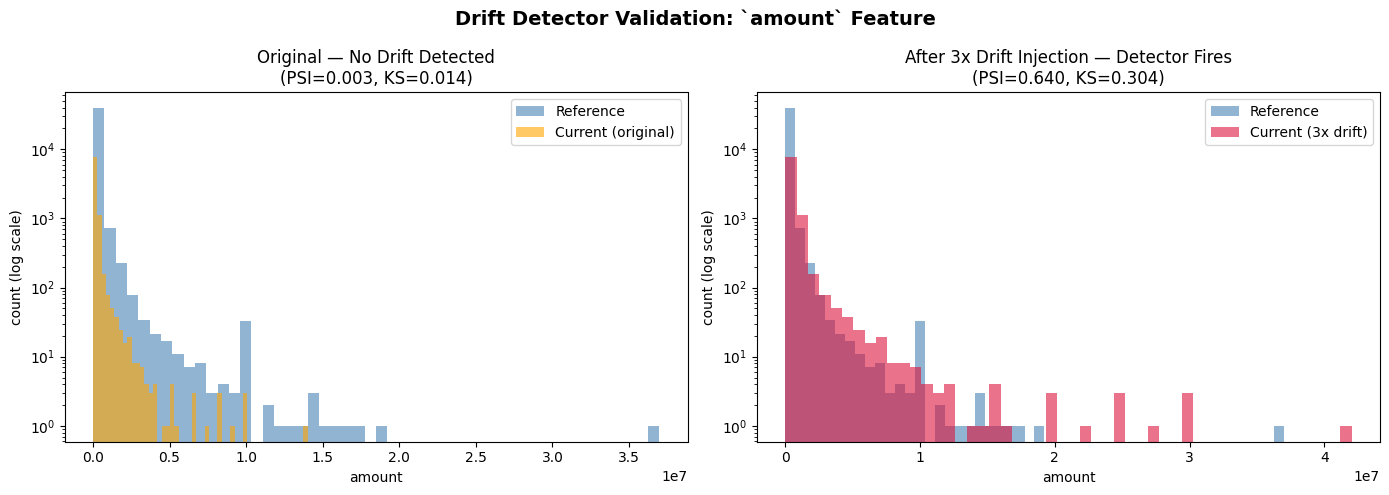

In [0]:
import matplotlib.pyplot as plt

# ---- 1. Pulling the three samples to driver ----
ref_amounts = reference_df.select("amount").toPandas()["amount"].values
cur_amounts = current_df.select("amount").toPandas()["amount"].values
cur_drift_amounts = current_drifted_df.select("amount").toPandas()["amount"].values

# ---- 2. Building side-by-side histograms ----
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: original (no drift)
axes[0].hist(ref_amounts, bins=50, alpha=0.6, label="Reference", color="steelblue")
axes[0].hist(cur_amounts, bins=50, alpha=0.6, label="Current (original)", color="orange")
axes[0].set_yscale("log")
axes[0].set_title("Original — No Drift Detected\n(PSI=0.003, KS=0.014)", fontsize=12)
axes[0].set_xlabel("amount")
axes[0].set_ylabel("count (log scale)")
axes[0].legend()

# Right panel: after drift injection
axes[1].hist(ref_amounts, bins=50, alpha=0.6, label="Reference", color="steelblue")
axes[1].hist(cur_drift_amounts, bins=50, alpha=0.6, label="Current (3x drift)", color="crimson")
axes[1].set_yscale("log")
axes[1].set_title("After 3x Drift Injection — Detector Fires\n(PSI=0.640, KS=0.304)", fontsize=12)
axes[1].set_xlabel("amount")
axes[1].set_ylabel("count (log scale)")
axes[1].legend()

plt.suptitle("Drift Detector Validation: `amount` Feature", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()